In [8]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 14.8 MB/s eta 0:00:00


In [5]:
import os
import glob
import pandas as pd
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# -------------------------------------------------------------------
# 1. Mount Google Drive and set up file paths
# -------------------------------------------------------------------
drive.mount('/content/drive')

BASE_DIR = '/content/drive/MyDrive/shl project/dataset'
TRAIN_CSV_PATH = os.path.join(BASE_DIR, 'train.csv')
TEST_CSV_PATH = os.path.join(BASE_DIR, 'test.csv')
TRAIN_AUDIO_DIR = os.path.join(BASE_DIR, 'train')
TEST_AUDIO_DIR = os.path.join(BASE_DIR, 'test')
TRAIN_FOLDS_CSV_PATH = os.path.join(BASE_DIR, 'train_folds.csv')
PREPROC_TRAIN_DIR = os.path.join(BASE_DIR, 'preprocessed_audio/train')
PREPROC_TEST_DIR = os.path.join(BASE_DIR, 'preprocessed_audio/test')
TRAIN_TRANSCRIPTS_CSV_PATH = os.path.join(BASE_DIR, 'train_transcripts.csv')
TEST_TRANSCRIPTS_CSV_PATH = os.path.join(BASE_DIR, 'test_transcripts.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking path availability:
Train CSV exists: True
Test CSV exists: True
Train Audio Dir exists: True
Test Audio Dir exists: True

--- TRAIN DATAFRAME INFO ---
Shape: (769, 2)
        filename  label
0  audio_192.wav    3.0
1  audio_436.wav    3.0
2  audio_447.wav    3.5
3  audio_126.wav    2.0
4   audio_61.wav    2.0

--- TEST DATAFRAME INFO ---
Shape: (216, 2)
        filename  label
0  audio_128.wav     -1
1  audio_156.wav     -1
2   audio_19.wav     -1
3  audio_108.wav     -1
4  audio_206.wav     -1

Missing values in train: {'filename': 0, 'label': 0}
Missing values in test: {'filename': 0, 'label': 0}

--- LABEL SUMMARY STATISTICS ---
count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


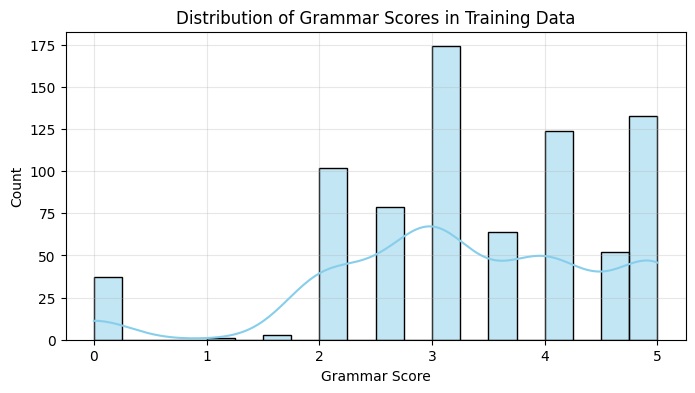


Inspecting train audio files...


KeyboardInterrupt: 

In [ ]:


# Verify path existence
print("Checking path availability:")
print("Train CSV exists:", os.path.exists(TRAIN_CSV_PATH))
print("Test CSV exists:", os.path.exists(TEST_CSV_PATH))
print("Train Audio Dir exists:", os.path.exists(TRAIN_AUDIO_DIR))
print("Test Audio Dir exists:", os.path.exists(TEST_AUDIO_DIR))

# -------------------------------------------------------------------
# 2. Inspect CSV Files
# -------------------------------------------------------------------
train_df = pd.read_csv(TRAIN_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

print("\n--- TRAIN DATAFRAME INFO ---")
print(f"Shape: {train_df.shape}")
print(train_df.head())

print("\n--- TEST DATAFRAME INFO ---")
print(f"Shape: {test_df.shape}")
print(test_df.head())

# Check missing values
print("\nMissing values in train:", train_df.isnull().sum().to_dict())
print("Missing values in test:", test_df.isnull().sum().to_dict())

# Summary statistics for labels
print("\n--- LABEL SUMMARY STATISTICS ---")
print(train_df['label'].describe())

# Plot score distribution
plt.figure(figsize=(8, 4))
sns.histplot(train_df['label'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Grammar Scores in Training Data')
plt.xlabel('Grammar Score')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------------------------------------------------
# 3. Audio File Verification and Metadata Inspection
# -------------------------------------------------------------------
def inspect_audio_folder(df, audio_dir, split_name='train'):
    durations = []
    sample_rates = []
    channels_list = []
    corrupt_files = []

    print(f"\nInspecting {split_name} audio files...")

    for idx, row in df.iterrows():
        filename = str(row['filename'])
        # Handle filename extension if missing
        if not filename.endswith('.wav'):
            filename += '.wav'

        file_path = os.path.join(audio_dir, filename)

        if not os.path.exists(file_path):
            corrupt_files.append((filename, "File missing"))
            continue

        try:
            # Quick metadata read using soundfile without loading entire array
            info = sf.info(file_path)
            durations.append(info.duration)
            sample_rates.append(info.samplerate)
            channels_list.append(info.channels)
        except Exception as e:
            corrupt_files.append((filename, str(e)))

    stats_df = pd.DataFrame({
        'duration_sec': durations,
        'sample_rate': sample_rates,
        'channels': channels_list
    })

    return stats_df, corrupt_files

train_audio_stats, train_corrupt = inspect_audio_folder(train_df, TRAIN_AUDIO_DIR, 'train')
test_audio_stats, test_corrupt = inspect_audio_folder(test_df, TEST_AUDIO_DIR, 'test')

print("\n--- AUDIO HEALTH REPORT ---")
print(f"Corrupt or missing files in train: {len(train_corrupt)}")
if train_corrupt:
    print("Train corrupt examples:", train_corrupt[:5])

print(f"Corrupt or missing files in test: {len(test_corrupt)}")
if test_corrupt:
    print("Test corrupt examples:", test_corrupt[:5])

print("\n--- TRAIN AUDIO METADATA STATS ---")
print(train_audio_stats.describe())

print("\nUnique Sample Rates in Train:", train_audio_stats['sample_rate'].value_counts().to_dict())
print("Unique Channel Counts in Train:", train_audio_stats['channels'].value_counts().to_dict())

# step 2 : Cross Validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold

# -------------------------------------------------------------------
# 1. Load train CSV
# -------------------------------------------------------------------
train_df = pd.read_csv(TRAIN_CSV_PATH)

# Ensure filename extensions are uniform (.wav)
train_df['filename'] = train_df['filename'].apply(
    lambda x: x if str(x).endswith('.wav') else f"{x}.wav"
)

# -------------------------------------------------------------------
# 2. Bin continuous scores into discrete bins for Stratification
# -------------------------------------------------------------------
# StratifiedKFold requires discrete class labels.
# We bin continuous grammar scores (1 to 5) into discrete categories.
num_bins = 5
train_df['strat_bin'] = pd.qcut(train_df['label'], q=num_bins, labels=False, duplicates='drop')

# -------------------------------------------------------------------
# 3. Create Stratified 5-Fold Splits
# -------------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

train_df['fold'] = -1
for fold, (train_idx, val_idx) in enumerate(skf.split(train_df, train_df['strat_bin'])):
    train_df.loc[val_idx, 'fold'] = fold

# Drop temporary binning column
train_df.drop(columns=['strat_bin'], inplace=True)

# -------------------------------------------------------------------
# 4. Verify Fold Balance
# -------------------------------------------------------------------
print("--- SAMPLES PER FOLD ---")
print(train_df['fold'].value_counts().sort_index())

print("\n--- LABEL MEAN & STD PER FOLD ---")
fold_stats = train_df.groupby('fold')['label'].agg(['count', 'mean', 'std', 'min', 'max'])
print(fold_stats)

# Save dataframe with fold assignments to Google Drive so it's reproducible
TRAIN_FOLDS_CSV_PATH = os.path.join(BASE_DIR, 'train_folds.csv')
train_df.to_csv(TRAIN_FOLDS_CSV_PATH, index=False)
print(f"\nSaved updated train dataframe with folds to: {TRAIN_FOLDS_CSV_PATH}")

--- SAMPLES PER FOLD ---
fold
0    154
1    154
2    154
3    154
4    153
Name: count, dtype: int64

--- LABEL MEAN & STD PER FOLD ---
      count      mean       std  min  max
fold                                     
0       154  3.324675  1.238717  0.0  5.0
1       154  3.347403  1.165024  0.0  5.0
2       154  3.292208  1.249446  0.0  5.0
3       154  3.253247  1.363922  0.0  5.0
4       153  3.349673  1.181108  0.0  5.0

Saved updated train dataframe with folds to: /content/drive/MyDrive/shl project/dataset/train_folds.csv


In [ ]:
train_df.head()

,filename,label,fold
0,audio_192.wav,3.0,4
1,audio_436.wav,3.0,4
2,audio_447.wav,3.5,3
3,audio_126.wav,2.0,2
4,audio_61.wav,2.0,0


# Step 3: Preproccess the audio

In [ ]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import pandas as pd
from tqdm import tqdm

# -------------------------------------------------------------------
# 1. Define Output Directories for Preprocessed Audio
# -------------------------------------------------------------------
PREPROC_TRAIN_DIR = os.path.join(BASE_DIR, 'preprocessed_audio/train')
PREPROC_TEST_DIR = os.path.join(BASE_DIR, 'preprocessed_audio/test')

os.makedirs(PREPROC_TRAIN_DIR, exist_ok=True)
os.makedirs(PREPROC_TEST_DIR, exist_ok=True)

TARGET_SAMPLE_RATE = 16000

# -------------------------------------------------------------------
# 2. Audio Processing Function (Mono, 16kHz, Volume Normalization)
# -------------------------------------------------------------------
def preprocess_and_save_audio(df, src_dir, dst_dir, desc="Processing Audio"):
    processed_count = 0

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        filename = str(row['filename'])
        if not filename.endswith('.wav'):
            filename += '.wav'

        src_path = os.path.join(src_dir, filename)
        dst_path = os.path.join(dst_dir, filename)

        # Skip processing if already processed (saves Colab time if rerun)
        if os.path.exists(dst_path):
            processed_count += 1
            continue

        try:
            # Load audio using torchaudio
            waveform, sample_rate = torchaudio.load(src_path)

            # 1. Convert Stereo to Mono (average channels)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)

            # 2. Resample to 16 kHz if necessary
            if sample_rate != TARGET_SAMPLE_RATE:
                resampler = T.Resample(orig_freq=sample_rate, new_freq=TARGET_SAMPLE_RATE)
                waveform = resampler(waveform)

            # 3. Peak Volume Normalization (Scale peak amplitude to 0.95 to prevent clipping)
            max_val = torch.max(torch.abs(waveform))
            if max_val > 0:
                waveform = (waveform / max_val) * 0.95

            # Save standardized audio
            torchaudio.save(dst_path, waveform, TARGET_SAMPLE_RATE)
            processed_count += 1

        except Exception as e:
            print(f"Error processing {filename}: {e}")

    print(f"Successfully preprocessed {processed_count}/{len(df)} files in {desc}.")

# Load train_folds metadata
train_folds_df = pd.read_csv(TRAIN_FOLDS_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

# Run preprocessing for train and test audio
preprocess_and_save_audio(train_folds_df, TRAIN_AUDIO_DIR, PREPROC_TRAIN_DIR, desc="Train Audio")
preprocess_and_save_audio(test_df, TEST_AUDIO_DIR, PREPROC_TEST_DIR, desc="Test Audio")

Train Audio: 100%|██████████| 769/769 [05:27<00:00,  2.35it/s]


Successfully preprocessed 769/769 files in Train Audio.


Test Audio: 100%|██████████| 216/216 [01:10<00:00,  3.07it/s]

Successfully preprocessed 216/216 files in Test Audio.


# step 4: Audio Transcription

In [ ]:
import os
import torch
import pandas as pd
from tqdm import tqdm
from transformers import pipeline

# -------------------------------------------------------------------
# 1. Load Pretrained Distil-Whisper / Whisper-Large-v3-Turbo on GPU
# -------------------------------------------------------------------
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

MODEL_ID = "distil-whisper/distil-large-v3"

print(f"Loading speech-to-text pipeline ({MODEL_ID}) on {device}...")
# Model choice: "distil-whisper/distil-large-v3" or "openai/whisper-large-v3-turbo"

print(f"Loading speech-to-text pipeline ({MODEL_ID}) on {device}...")

pipe = pipeline(
    "automatic-speech-recognition",
    model=MODEL_ID,
    torch_dtype=torch_dtype,
    device=device,
    chunk_length_s=30,
    model_kwargs={"attn_implementation": "sdpa"} # Efficient GPU memory usage
)

# Prompt telling the model to retain raw spoken grammar mistakes
VERBATIM_PROMPT = (
    "Transcribe the spoken audio verbatim. Include all grammatical errors, broken sentences, "
    "incomplete words, and filler words exactly as spoken. Do not fix grammar."
)

# Convert prompt_ids to PyTorch Tensor to prevent numpy.ndarray mismatch
raw_prompt_ids = pipe.tokenizer.get_prompt_ids(VERBATIM_PROMPT)
prompt_ids_tensor = torch.tensor(raw_prompt_ids, device=device)

# -------------------------------------------------------------------
# 2. Transcription Function
# -------------------------------------------------------------------
def transcribe_dataset_hf(df, audio_dir, desc="Transcribing Audio"):
    transcripts = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        filename = str(row['filename'])
        if not filename.endswith('.wav'):
            filename += '.wav'

        audio_path = os.path.join(audio_dir, filename)

        try:
            # Generate transcript
            result = pipe(
                audio_path,
                return_timestamps=True,
                generate_kwargs={
                    "language": "english",
                    "prompt_ids": prompt_ids_tensor,
                }
            )
            transcript_text = result["text"].strip()
        except Exception as e:
            print(f"Error transcribing {filename}: {e}")
            transcript_text = ""

        transcripts.append(transcript_text)

    df['transcript'] = transcripts
    return df

# -------------------------------------------------------------------
# 3. Transcribe Train and Test Splits
# -------------------------------------------------------------------
train_folds_df = pd.read_csv(TRAIN_FOLDS_CSV_PATH)
test_df = pd.read_csv(TEST_CSV_PATH)

print("\n--- Starting Train Audio Transcription ---")
train_transcribed_df = transcribe_dataset_hf(
    train_folds_df, PREPROC_TRAIN_DIR, desc="Train Audio Transcripts"
)

print("\n--- Starting Test Audio Transcription ---")
test_transcribed_df = transcribe_dataset_hf(
    test_df, PREPROC_TEST_DIR, desc="Test Audio Transcripts"
)

# Save transcribed dataframes to Google Drive
TRAIN_TRANSCRIPTS_CSV_PATH = os.path.join(BASE_DIR, 'train_transcripts.csv')
TEST_TRANSCRIPTS_CSV_PATH = os.path.join(BASE_DIR, 'test_transcripts.csv')

train_transcribed_df.to_csv(TRAIN_TRANSCRIPTS_CSV_PATH, index=False)
test_transcribed_df.to_csv(TEST_TRANSCRIPTS_CSV_PATH, index=False)

print("\n--- TRANSCRIPTION SUMMARY ---")
print(f"Saved train transcripts to: {TRAIN_TRANSCRIPTS_CSV_PATH}")
print(f"Saved test transcripts to: {TEST_TRANSCRIPTS_CSV_PATH}")

print("\nSample Train Transcripts:")
print(train_transcribed_df[['filename', 'label', 'transcript']].head())

Loading speech-to-text pipeline (distil-whisper/distil-large-v3) on cuda:0...
Loading speech-to-text pipeline (distil-whisper/distil-large-v3) on cuda:0...


Loading weights:   0%|          | 0/539 [00:00<?, ?it/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on its own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).



--- Starting Train Audio Transcription ---


Train Audio Transcripts:   0%|          | 0/769 [00:00<?, ?it/s][transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
Train Audio Transcripts: 100%|██████████| 769/769 [34:58<00:00,  2.73s/it]



--- Starting Test Audio Transcription ---


Test Audio Transcripts: 100%|██████████| 216/216 [09:18<00:00,  2.59s/it]


--- TRANSCRIPTION SUMMARY ---
Saved train transcripts to: /content/drive/MyDrive/shl project/dataset/train_transcripts.csv
Saved test transcripts to: /content/drive/MyDrive/shl project/dataset/test_transcripts.csv

Sample Train Transcripts:
        filename  label                                         transcript
0  audio_192.wav    3.0  Well, this, the playground is very, very beaut...
1  audio_436.wav    3.0  The scene of a school playground, our playgrou...
2  audio_447.wav    3.5  My favorite place to visit is the beach. I lov...
3  audio_126.wav    2.0  Once upon a time, we, with five friends, went ...
4   audio_61.wav    2.0  Well, when I was a child, I remember I went to...


# Step 5 Model

In [2]:
import os
import torch
import torch.nn as nn
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

# -------------------------------------------------------------------
# 1. Configuration & Hyperparameters
# -------------------------------------------------------------------
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 256  # 45-60 sec audio transcripts comfortably fit within 256 tokens

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device for model building: {device}")

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -------------------------------------------------------------------
# 2. PyTorch Dataset Class
# -------------------------------------------------------------------
class GrammarDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256, is_test=False):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        # Handle potential empty or NaN transcripts gracefully
        text = str(self.df.loc[index, 'transcript'])
        if not text or text == 'nan':
            text = "empty spoken transcript"

        # Tokenize sequence with truncation and padding
        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        item = {
            'input_ids': inputs['input_ids'].squeeze(0),
            'attention_mask': inputs['attention_mask'].squeeze(0)
        }

        # Add float label for regression if training/validation
        if not self.is_test:
            item['labels'] = torch.tensor(self.df.loc[index, 'label'], dtype=torch.float)

        return item

# -------------------------------------------------------------------
# 3. Model Architecture Factory Function
# -------------------------------------------------------------------
def build_model(model_name=MODEL_NAME):
    """
    Loads pretrained DeBERTa-v3 backbone with num_labels=1 for regression.
    """
    config = AutoConfig.from_pretrained(model_name)
    config.num_labels = 1  # Single output node for regression score

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config
    )
    return model

# -------------------------------------------------------------------
# 4. Verify Model Setup with a Dummy Batch
# -------------------------------------------------------------------
# Load transcribed training metadata
train_transcribed_df = pd.read_csv(TRAIN_TRANSCRIPTS_CSV_PATH)

sample_dataset = GrammarDataset(train_transcribed_df.head(4), tokenizer, max_len=MAX_LEN)
sample_loader = DataLoader(sample_dataset, batch_size=2, shuffle=False)

# Test forward pass
model = build_model().to(device)
model.eval()

for batch in sample_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits.squeeze(-1)  # Shape: (batch_size,)

    print("\n--- MODEL FORWARD PASS TEST SUCCESSFUL ---")
    print(f"Batch Input IDs Shape: {input_ids.shape}")
    print(f"Batch Target Labels: {labels.cpu().tolist()}")
    print(f"Model Predicted Raw Output Scores: {logits.cpu().tolist()}")
    break

Using device for model building: cuda


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier


--- MODEL FORWARD PASS TEST SUCCESSFUL ---
Batch Input IDs Shape: torch.Size([2, 256])
Batch Target Labels: [3.0, 3.0]
Model Predicted Raw Output Scores: [-0.258544921875, -0.2342529296875]


# step 6: Model training

In [4]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from tqdm import tqdm

# -------------------------------------------------------------------
# 1. Reproducibility & Seed Setting
# -------------------------------------------------------------------
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

# Clear any lingering FP16 GPU cached memory from Step 4
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# -------------------------------------------------------------------
# 2. Training Hyperparameters
# -------------------------------------------------------------------
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODELS_DIR = os.path.join(BASE_DIR, 'saved_models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Load transcribed dataset
train_df = pd.read_csv(TRAIN_TRANSCRIPTS_CSV_PATH)

# Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# -------------------------------------------------------------------
# 3. Single Fold Training Function
# -------------------------------------------------------------------
def train_single_fold(fold_num, train_df):
    print(f"\n==================================================")
    print(f"            STARTING TRAINING FOR FOLD {fold_num}")
    print(f"==================================================")

    # Split train/val for current fold
    train_data = train_df[train_df['fold'] != fold_num].reset_index(drop=True)
    val_data = train_df[train_df['fold'] == fold_num].reset_index(drop=True)

    # Datasets & Loaders
    train_dataset = GrammarDataset(train_data, tokenizer, max_len=MAX_LEN)
    val_dataset = GrammarDataset(val_data, tokenizer, max_len=MAX_LEN)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Initialize Model, Optimizer, Loss, Scheduler
    model = build_model(MODEL_NAME).to(DEVICE).float()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps = len(train_loader) * EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * 0.1),
        num_training_steps=total_steps
    )

    criterion = nn.MSELoss()

    best_val_rmse = float('inf')
    best_model_path = os.path.join(MODELS_DIR, f'deberta_fold_{fold_num}.pt')

    val_preds_out = []

    for epoch in range(1, EPOCHS + 1):
        # --- Training Phase ---
        model.train()
        train_loss_sum = 0.0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]"):
            input_ids = batch['input_ids'].to(DEVICE,dtype=torch.long)
            attention_mask = batch['attention_mask'].to(DEVICE,dtype=torch.long)
            labels = batch['labels'].to(DEVICE, dtype=torch.float32)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)

            loss = criterion(logits, labels)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            train_loss_sum += loss.item() * len(labels)

        epoch_train_mse = train_loss_sum / len(train_data)
        epoch_train_rmse = np.sqrt(epoch_train_mse)

        # --- Validation Phase ---
        model.eval()
        val_loss_sum = 0.0
        current_epoch_preds = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]"):
                input_ids = batch['input_ids'].to(DEVICE, dtype=torch.long)
                attention_mask = batch['attention_mask'].to(DEVICE, dtype=torch.long)
                labels = batch['labels'].to(DEVICE, dtype=torch.float32)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                logits = outputs.logits.squeeze(-1)

                loss = criterion(logits, labels)
                val_loss_sum += loss.item() * len(labels)
                current_epoch_preds.extend(logits.cpu().numpy())

        epoch_val_mse = val_loss_sum / len(val_data)
        epoch_val_rmse = np.sqrt(epoch_val_mse)

        print(f"Fold {fold_num} | Epoch {epoch}/{EPOCHS} | Train RMSE: {epoch_train_rmse:.4f} | Val RMSE: {epoch_val_rmse:.4f}")

        # Save checkpoint if validation RMSE improves
        if epoch_val_rmse < best_val_rmse:
            best_val_rmse = epoch_val_rmse
            val_preds_out = current_epoch_preds
            torch.save(model.state_dict(), best_model_path)
            print(f"--> Saved new best checkpoint for Fold {fold_num} with Val RMSE: {best_val_rmse:.4f}")

    return val_data, val_preds_out

# -------------------------------------------------------------------
# 4. Run 5-Fold Cross-Validation Training Loop
# -------------------------------------------------------------------
oof_dfs = []

for fold in range(5):
    val_data_fold, val_preds_fold = train_single_fold(fold, train_df)
    val_data_fold['oof_pred'] = val_preds_fold
    oof_dfs.append(val_data_fold)

# Combine out-of-fold predictions into a single dataframe
oof_df = pd.concat(oof_dfs, ignore_index=True)
OOF_CSV_PATH = os.path.join(BASE_DIR, 'oof_predictions.csv')
oof_df.to_csv(OOF_CSV_PATH, index=False)

print("\n==================================================")
print("       5-FOLD TRAINING COMPLETE & SAVED")
print(f"OOF predictions saved to: {OOF_CSV_PATH}")
print("==================================================")


            STARTING TRAINING FOR FOLD 0


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
pooler.dense.weight                     | MISSING    | 
classifier

Fold 0 | Epoch 1/4 | Train RMSE: 2.2323 | Val RMSE: 0.9971
--> Saved new best checkpoint for Fold 0 with Val RMSE: 0.9971


Epoch 2/4 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.55it/s]


...

Fold 4 | Epoch 2/4 | Train RMSE: 0.9042 | Val RMSE: 0.8093
--> Saved new best checkpoint for Fold 4 with Val RMSE: 0.8093


Epoch 3/4 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.72it/s]


Fold 4 | Epoch 3/4 | Train RMSE: 0.7140 | Val RMSE: 0.9969


Epoch 4/4 [Val]: 100%|██████████| 20/20 [00:03<00:00,  5.87it/s]

Fold 4 | Epoch 4/4 | Train RMSE: 0.6007 | Val RMSE: 0.8205

       5-FOLD TRAINING COMPLETE & SAVED
OOF predictions saved to: /content/drive/MyDrive/shl project/dataset/oof_predictions.csv


# Step 7 : Evaluation and Error Analysis

     OUT-OF-FOLD (OOF) EVALUATION REPORT          
Raw OOF RMSE           : 0.8285
Clipped [1, 5] OOF RMSE: 0.8267 (Official Competition Metric)
Pearson Correlation (r): 0.7576
Quadratic Weighted Kappa: 0.7130



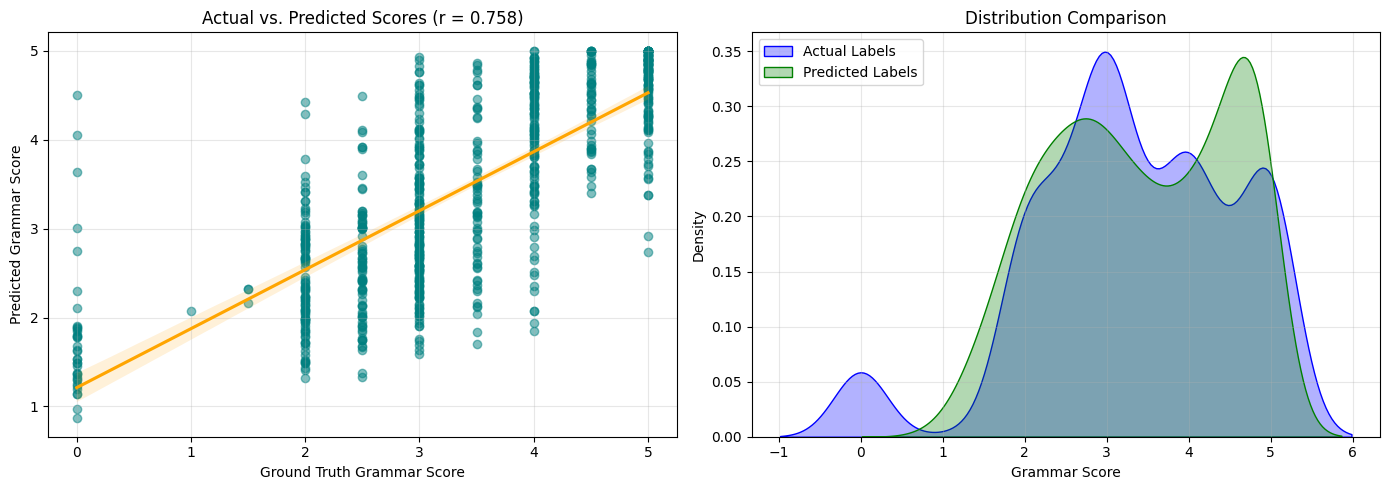


     TOP 5 LARGEST PREDICTION ERRORS (ANALYSIS)   

Filename       : audio_5044.wav
Actual Label   : 0.0
Predicted Label: 4.50 (Error: 4.50)
Transcript     : "I honestly don't think I've had the best day of my life or anything close to it, so I cannot really give my opinion on this experience or what made it special."
------------------------------------------------------------

Filename       : audio_5045.wav
Actual Label   : 0.0
Predicted Label: 4.05 (Error: 4.05)
Transcript     : "There were slides and monkey bars and swing sets. They were all colorful. There was like a big jungle game. You hear laughter, kids running, chasing together, laughing. Some kids crying. A lot of kids smiling. There was a lot, it was a big, there's a heart of kids playing on the monkey bars. And they're running around. A lot of kids waiting in line for the slides. Kids pushing each other on a stream so."
------------------------------------------------------------

Filename       : audio_5040.wav
Actual L

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, cohen_kappa_score

# -------------------------------------------------------------------
# 1. Load Out-of-Fold Predictions
# -------------------------------------------------------------------
oof_df = pd.read_csv(OOF_CSV_PATH)

# Post-processing: Clip raw predictions strictly to valid [0.0, 5.0] rubric range
oof_df['oof_pred_clipped'] = np.clip(oof_df['oof_pred'], 0.0, 5.0)

# Calculate absolute residual error
oof_df['abs_error'] = np.abs(oof_df['label'] - oof_df['oof_pred_clipped'])

# -------------------------------------------------------------------
# 2. Compute Official Metrics
# -------------------------------------------------------------------
y_true = oof_df['label'].values
y_pred_raw = oof_df['oof_pred'].values
y_pred_clip = oof_df['oof_pred_clipped'].values

# RMSE
rmse_raw = np.sqrt(mean_squared_error(y_true, y_pred_raw))
rmse_clip = np.sqrt(mean_squared_error(y_true, y_pred_clip))

# Pearson Correlation
pearson_corr, _ = pearsonr(y_true, y_pred_clip)

# Quadratic Weighted Kappa (QWK) on rounded scores (1 to 5 integers)
qwk_score = cohen_kappa_score(
    np.round(y_true).astype(int),
    np.round(y_pred_clip).astype(int),
    weights='quadratic'
)

print("==================================================")
print("     OUT-OF-FOLD (OOF) EVALUATION REPORT          ")
print("==================================================")
print(f"Raw OOF RMSE           : {rmse_raw:.4f}")
print(f"Clipped [1, 5] OOF RMSE: {rmse_clip:.4f} (Official Competition Metric)")
print(f"Pearson Correlation (r): {pearson_corr:.4f}")
print(f"Quadratic Weighted Kappa: {qwk_score:.4f}")
print("==================================================\n")

# -------------------------------------------------------------------
# 3. Plot Actual vs. Predicted Distributions & Scatter
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Actual vs Predicted
sns.regplot(
    x='label', y='oof_pred_clipped', data=oof_df, ax=axes[0],
    color='teal', scatter_kws={'alpha':0.5}, line_kws={'color':'orange'}
)
axes[0].set_title(f'Actual vs. Predicted Scores (r = {pearson_corr:.3f})')
axes[0].set_xlabel('Ground Truth Grammar Score')
axes[0].set_ylabel('Predicted Grammar Score')
axes[0].grid(True, alpha=0.3)

# Distribution Comparison
sns.kdeplot(oof_df['label'], label='Actual Labels', ax=axes[1], color='blue', fill=True, alpha=0.3)
sns.kdeplot(oof_df['oof_pred_clipped'], label='Predicted Labels', ax=axes[1], color='green', fill=True, alpha=0.3)
axes[1].set_title('Distribution Comparison')
axes[1].set_xlabel('Grammar Score')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 4. Error Analysis: Inspect Top 5 Highest Residuals
# -------------------------------------------------------------------
worst_errors = oof_df.sort_values(by='abs_error', ascending=False).head(5)

print("\n==================================================")
print("     TOP 5 LARGEST PREDICTION ERRORS (ANALYSIS)   ")
print("==================================================")

for idx, row in worst_errors.iterrows():
    print(f"\nFilename       : {row['filename']}")
    print(f"Actual Label   : {row['label']}")
    print(f"Predicted Label: {row['oof_pred_clipped']:.2f} (Error: {row['abs_error']:.2f})")
    print(f"Transcript     : \"{row['transcript']}\"")
    print("-" * 60)

# Step 9 : Improving ( DeBERTa + Ensemble ) Model

In [9]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings('ignore')

# Suppress Optuna verbose logging for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -------------------------------------------------------------------
# 1. Load Data & Prepare Features
# -------------------------------------------------------------------
oof_df = pd.read_csv(OOF_CSV_PATH)
oof_df['transcript'] = oof_df['transcript'].fillna("")

def extract_meta_features(df):
    df_feat = df.copy()
    df_feat['char_count'] = df_feat['transcript'].apply(len)
    df_feat['word_count'] = df_feat['transcript'].apply(lambda x: len(x.split()))
    df_feat['avg_word_len'] = df_feat['char_count'] / (df_feat['word_count'] + 1e-5)
    df_feat['unique_word_count'] = df_feat['transcript'].apply(lambda x: len(set(x.lower().split())))
    df_feat['ttr'] = df_feat['unique_word_count'] / (df_feat['word_count'] + 1e-5)
    df_feat['comma_count'] = df_feat['transcript'].apply(lambda x: x.count(','))
    df_feat['period_count'] = df_feat['transcript'].apply(lambda x: x.count('.'))
    df_feat['question_count'] = df_feat['transcript'].apply(lambda x: x.count('?'))
    return df_feat

df_features = extract_meta_features(oof_df)
feature_cols = [
    'char_count', 'word_count', 'avg_word_len',
    'unique_word_count', 'ttr', 'comma_count',
    'period_count', 'question_count'
]

# -------------------------------------------------------------------
# 2. Optuna Objective Function (5-Fold CV Evaluation)
# -------------------------------------------------------------------
def objective(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 7, 31),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30)
    }

    oof_preds = np.zeros(len(df_features))

    for fold in range(5):
        train_idx = df_features['fold'] != fold
        val_idx = df_features['fold'] == fold

        X_train, y_train = df_features.loc[train_idx, feature_cols], df_features.loc[train_idx, 'label']
        X_val, y_val = df_features.loc[val_idx, feature_cols], df_features.loc[val_idx, 'label']

        train_data = lgb.Dataset(X_train, label=y_train)
        val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

        model = lgb.train(
            params,
            train_data,
            num_boost_round=400,
            valid_sets=[val_data],
            callbacks=[lgb.early_stopping(30, verbose=False)]
        )
        oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)

    return np.sqrt(mean_squared_error(df_features['label'], oof_preds))

print("Starting Optuna Hyperparameter Optimization (50 trials)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print("\nBest Optuna Trial Parameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

# -------------------------------------------------------------------
# 3. Train Final LightGBM with Best Parameters & Evaluate
# -------------------------------------------------------------------
best_lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'verbosity': -1,
    'random_state': 42,
    **study.best_params
}

tuned_lgb_oof_preds = np.zeros(len(df_features))

for fold in range(5):
    train_idx = df_features['fold'] != fold
    val_idx = df_features['fold'] == fold

    X_train, y_train = df_features.loc[train_idx, feature_cols], df_features.loc[train_idx, 'label']
    X_val, y_val = df_features.loc[val_idx, feature_cols], df_features.loc[val_idx, 'label']

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    model = lgb.train(
        best_lgb_params,
        train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(40, verbose=False)]
    )
    tuned_lgb_oof_preds[val_idx] = model.predict(X_val, num_iteration=model.best_iteration)

df_features['tuned_lgb_oof_pred'] = tuned_lgb_oof_preds

# -------------------------------------------------------------------
# 4. Ensemble Search with Tuned LightGBM
# -------------------------------------------------------------------
best_weight = 1.0
best_ensemble_rmse = float('inf')

y_true = df_features['label'].values
deberta_preds = df_features['oof_pred'].values
tuned_lgb_preds = df_features['tuned_lgb_oof_pred'].values

for w in np.linspace(0.5, 1.0, 51):
    blended = w * deberta_preds + (1.0 - w) * tuned_lgb_preds
    blended_clipped = np.clip(blended, 0.0, 5.0)
    rmse = np.sqrt(mean_squared_error(y_true, blended_clipped))

    if rmse < best_ensemble_rmse:
        best_ensemble_rmse = rmse
        best_weight = w

deberta_baseline_rmse = np.sqrt(mean_squared_error(y_true, np.clip(deberta_preds, 0.0, 5.0)))
tuned_lgb_baseline_rmse = np.sqrt(mean_squared_error(y_true, np.clip(tuned_lgb_preds, 0.0, 5.0)))

final_ensemble_oof = np.clip(best_weight * deberta_preds + (1.0 - best_weight) * tuned_lgb_preds, 0.0, 5.0)
final_corr, _ = pearsonr(y_true, final_ensemble_oof)

print("\n==================================================")
print("     TUNED ENSEMBLE IMPROVEMENT SUMMARY           ")
print("==================================================")
print(f"DeBERTa-v3 Single Model RMSE : {deberta_baseline_rmse:.4f}")
print(f"Tuned LightGBM Model RMSE    : {tuned_lgb_baseline_rmse:.4f}")
print(f"Optimal DeBERTa Weight (w)  : {best_weight:.2f}")
print(f"Tuned Ensemble (DeBERTa+LGB) : {best_ensemble_rmse:.4f}")
print(f"Pearson Correlation (r)      : {final_corr:.4f}")
print("==================================================")

df_features['ensemble_oof_pred'] = final_ensemble_oof
df_features.to_csv(os.path.join(BASE_DIR, 'tuned_improved_oof_predictions.csv'), index=False)

Starting Optuna Hyperparameter Optimization (50 trials)...

Best Optuna Trial Parameters:
  learning_rate: 0.013053205731448433
  num_leaves: 26
  max_depth: 3
  feature_fraction: 0.6944841411040292
  bagging_fraction: 0.643027522189135
  bagging_freq: 2
  reg_alpha: 3.3324015429839102
  reg_lambda: 4.7958467273440695
  min_child_samples: 9

     TUNED ENSEMBLE IMPROVEMENT SUMMARY           
DeBERTa-v3 Single Model RMSE : 0.8267
Tuned LightGBM Model RMSE    : 1.1287
Optimal DeBERTa Weight (w)  : 0.81
Tuned Ensemble (DeBERTa+LGB) : 0.8056
Pearson Correlation (r)      : 0.7624


# Step 9 : Submission

In [10]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import lightgbm as lgb
from tqdm import tqdm

MODEL_NAME = "microsoft/deberta-v3-base"
MODEL_NAME = "microsoft/deberta-v3-base"
MAX_LEN = 256
BATCH_SIZE = 8
EPOCHS = 4
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

# -------------------------------------------------------------------
# 1. Configuration & Paths
# -------------------------------------------------------------------
TEST_TRANSCRIPTS_CSV_PATH = os.path.join(BASE_DIR, 'test_transcripts.csv')  # Update filename if needed
SUBMISSION_PATH = os.path.join(BASE_DIR, 'submission.csv')

# Load pre-transcribed test CSV
test_df = pd.read_csv(TEST_TRANSCRIPTS_CSV_PATH)
test_df['transcript'] = test_df['transcript'].fillna("")

# Ensure 'filename' column exists
if 'filename' not in test_df.columns and 'filepath' in test_df.columns:
    test_df['filename'] = test_df['filepath'].apply(lambda x: os.path.basename(x))

print(f"Loaded test transcripts CSV with {len(test_df)} samples.")

# -------------------------------------------------------------------
# 2. Extract Tabular Metadata Features on Test Transcripts
# -------------------------------------------------------------------
print("\n--- Step 9A: Extracting Tabular Metadata Features ---")

def extract_meta_features(df):
    df_feat = df.copy()
    df_feat['char_count'] = df_feat['transcript'].apply(len)
    df_feat['word_count'] = df_feat['transcript'].apply(lambda x: len(x.split()))
    df_feat['avg_word_len'] = df_feat['char_count'] / (df_feat['word_count'] + 1e-5)
    df_feat['unique_word_count'] = df_feat['transcript'].apply(lambda x: len(set(x.lower().split())))
    df_feat['ttr'] = df_feat['unique_word_count'] / (df_feat['word_count'] + 1e-5)
    df_feat['comma_count'] = df_feat['transcript'].apply(lambda x: x.count(','))
    df_feat['period_count'] = df_feat['transcript'].apply(lambda x: x.count('.'))
    df_feat['question_count'] = df_feat['transcript'].apply(lambda x: x.count('?'))
    return df_feat

test_df = extract_meta_features(test_df)
feature_cols = [
    'char_count', 'word_count', 'avg_word_len',
    'unique_word_count', 'ttr', 'comma_count',
    'period_count', 'question_count'
]

# -------------------------------------------------------------------
# 3. DeBERTa 5-Fold Ensemble Inference
# -------------------------------------------------------------------
print("\n--- Step 9B: Running DeBERTa 5-Fold Inference ---")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class TestDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=256):
        self.texts = df['transcript'].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0)
        }

test_dataset = TestDataset(test_df, tokenizer, max_len=MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

deberta_fold_preds = []

for fold in range(5):
    print(f"Predicting with DeBERTa Fold {fold}...")
    model = build_model(MODEL_NAME).to(DEVICE).float()
    checkpoint_path = os.path.join(MODELS_DIR, f'deberta_fold_{fold}.pt')
    model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    model.eval()

    fold_preds = []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"DeBERTa Fold {fold}"):
            input_ids = batch['input_ids'].to(DEVICE, dtype=torch.long)
            attention_mask = batch['attention_mask'].to(DEVICE, dtype=torch.long)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits.squeeze(-1)
            fold_preds.extend(logits.cpu().numpy())

    deberta_fold_preds.append(fold_preds)

deberta_test_preds = np.mean(deberta_fold_preds, axis=0)

# -------------------------------------------------------------------
# 4. LightGBM 5-Fold Ensemble Inference
# -------------------------------------------------------------------
print("\n--- Step 9C: Running LightGBM 5-Fold Inference ---")

oof_df = pd.read_csv(OOF_CSV_PATH)
oof_df['transcript'] = oof_df['transcript'].fillna("")
oof_df_feat = extract_meta_features(oof_df)

lgb_fold_preds = []

for fold in range(5):
    train_idx = oof_df_feat['fold'] != fold
    val_idx = oof_df_feat['fold'] == fold

    X_train, y_train = oof_df_feat.loc[train_idx, feature_cols], oof_df_feat.loc[train_idx, 'label']
    X_val, y_val = oof_df_feat.loc[val_idx, feature_cols], oof_df_feat.loc[val_idx, 'label']

    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    model = lgb.train(
        best_lgb_params,
        train_data,
        num_boost_round=500,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(40, verbose=False)]
    )

    lgb_fold_preds.append(model.predict(test_df[feature_cols], num_iteration=model.best_iteration))

lgb_test_preds = np.mean(lgb_fold_preds, axis=0)

# -------------------------------------------------------------------
# 5. Final Blend & CSV Export
# -------------------------------------------------------------------
print("\n--- Step 9D: Blending Predictions & Exporting ---")

final_test_preds = (best_weight * deberta_test_preds) + ((1.0 - best_weight) * lgb_test_preds)
final_test_preds_clipped = np.clip(final_test_preds, 0.0, 5.0)

submission_df = pd.DataFrame({
    'filename': test_df['filename'],
    'label': final_test_preds_clipped
})

submission_df.to_csv(SUBMISSION_PATH, index=False)

print("\n==================================================")
print("       SUBMISSION GENERATION COMPLETE!            ")
print("==================================================")
print(f"Total Test Predictions Generated: {len(submission_df)}")
print(f"Submission saved to             : {SUBMISSION_PATH}\n")
print("Preview of First 5 Submission Rows:")
print(submission_df.head())

Loaded test transcripts CSV with 216 samples.

--- Step 9A: Extracting Tabular Metadata Features ---

--- Step 9B: Running DeBERTa 5-Fold Inference ---
Predicting with DeBERTa Fold 0...


NameError: name 'build_model' is not defined

# Step 10 : Post Clipping

In [6]:
from scipy.optimize import minimize
from sklearn.metrics import mean_squared_error
import numpy as np
import os


best_weight = 0.81
lgm_tuned_oof = pd.read_csv(os.path.join(BASE_DIR, 'tuned_improved_oof_predictions.csv'))

deberta_preds = lgm_tuned_oof['oof_pred'].values
tuned_lgb_preds = lgm_tuned_oof['tuned_lgb_oof_pred'].values



# -------------------------------------------------------------------
# 1. Combine OOF predictions from your models
final_ensemble_oof = (best_weight * deberta_preds + ((1.0 - best_weight) * tuned_lgb_preds)
y_true = lgm_tuned_oof['label'].values

# 2. Objective function to find best clipping bounds on OOF data
def objective_loss(bounds):
    lower, upper = bounds
    # Prevent inverted bounds during search
    if lower >= upper:
        return 1e5

    clipped_oof = np.clip(final_ensemble_oof, lower, upper)
    return np.sqrt(mean_squared_error(y_true, clipped_oof))

# 3. Fit bounds strictly on OOF predictions
res = minimize(objective_loss, x0=[0.0, 5.0], method='Nelder-Mead')
best_lower, best_upper = res.x

print(f"Optimal OOF Lower Bound: {best_lower:.4f}")
print(f"Optimal OOF Upper Bound: {best_upper:.4f}")

# 4. Apply learned parameters directly to test set
final_test_preds = (best_weight * deberta_test_preds) + ((1.0 - best_weight) * lgb_test_preds)
final_test_preds_clipped = np.clip(final_test_preds, best_lower, best_upper)

submission_df = pd.DataFrame({
    'filename': test_df['filename'],
    'label': final_test_preds_clipped
})

SUBMISSION_PATH = os.path.join(BASE_DIR, 'Post_Process_Optimization_Submission.csv')

submission_df.to_csv(SUBMISSION_PATH, index=False)"""


'\n\n# -------------------------------------------------------------------\n# 1. Combine OOF predictions from your models\nfinal_ensemble_oof = (best_weight * deberta_preds + (1.0 - best_weight) * tuned_lgb_preds)\ny_true = final_ensemble_oof[\'label\'].values\n\n# 2. Objective function to find best clipping bounds on OOF data\ndef objective_loss(bounds):\n    lower, upper = bounds\n    # Prevent inverted bounds during search\n    if lower >= upper:\n        return 1e5\n    \n    clipped_oof = np.clip(oof_blend, lower, upper)\n    return np.sqrt(mean_squared_error(y_true, clipped_oof))\n\n# 3. Fit bounds strictly on OOF predictions\nres = minimize(objective_loss, x0=[0.0, 5.0], method=\'Nelder-Mead\')\nbest_lower, best_upper = res.x\n\nprint(f"Optimal OOF Lower Bound: {best_lower:.4f}")\nprint(f"Optimal OOF Upper Bound: {best_upper:.4f}")\n\n# 4. Apply learned parameters directly to test set\nfinal_test_preds_clipped = np.clip(final_test_preds, best_lower, best_upper)\n\nsubmission_df 